# MNIST Denoising Autoencoder
A deep learning model that removes noise from MNIST images using a convolutional autoencoder.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 2. Load & Preprocess Data

In [2]:
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

print("Train:", x_train.shape)
print("Test :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1)
Test : (10000, 28, 28, 1)


## 3. Add Gaussian Noise

In [3]:
noise_factor = 0.4

x_train_noisy = x_train + noise_factor * np.random.normal(size=x_train.shape)
x_test_noisy  = x_test  + noise_factor * np.random.normal(size=x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)

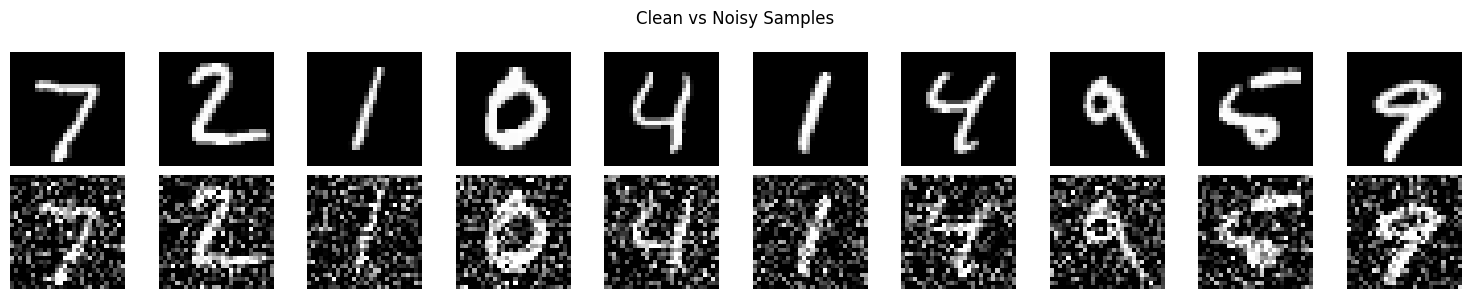

In [4]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    axes[0, i].imshow(x_test[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Clean',  fontsize=10)
axes[1, 0].set_ylabel('Noisy',  fontsize=10)
plt.suptitle('Clean vs Noisy Samples')
plt.tight_layout()
plt.show()

## 4. Build Convolutional Autoencoder

In [5]:
def build_autoencoder():
    inputs = layers.Input(shape=(28, 28, 1))

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D(2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D(2, padding='same')(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.UpSampling2D(2)(x)
    decoded = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    return models.Model(inputs, decoded, name='denoising_autoencoder')

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile & Train

In [6]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=30,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.1452 - mae: 0.0707 - val_loss: 0.1027 - val_mae: 0.0414
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0981 - mae: 0.0380 - val_loss: 0.0959 - val_mae: 0.0364
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0936 - mae: 0.0348 - val_loss: 0.0932 - val_mae: 0.0348
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0913 - mae: 0.0331 - val_loss: 0.0912 - val_mae: 0.0325
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0898 - mae: 0.0320 - val_loss: 0.0906 - val_mae: 0.0324
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0887 - mae: 0.0312 - val_loss: 0.0893 - val_mae: 0.0315
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0879 - mae: 0.0306 - val_loss: 0.0886 - val_mae: 0.0307
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0874 - mae: 0.0302 - val_loss: 0.0881 - val_mae: 0.0304
Epoch 9/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - 

## 6. Training Curves

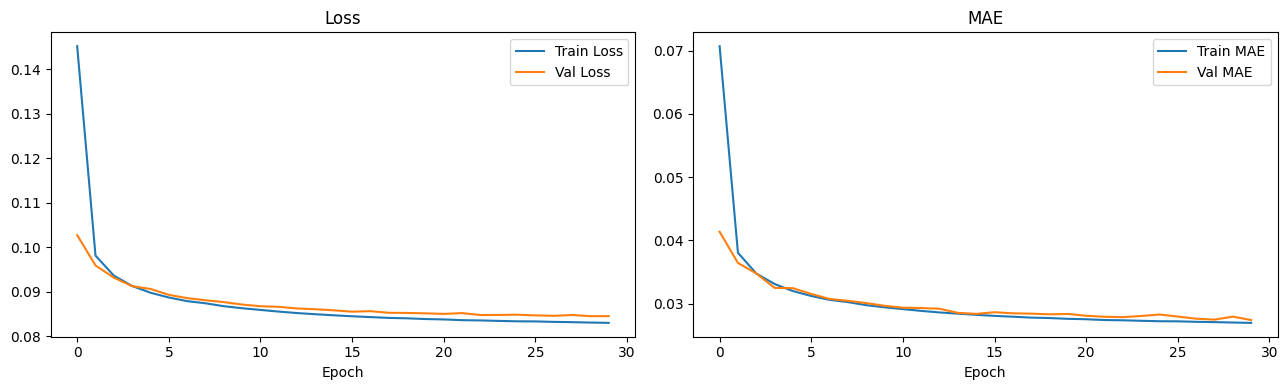

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Evaluate on Test Set

In [8]:
test_loss, test_mae = autoencoder.evaluate(x_test_noisy, x_test, verbose=0)
print(f"Test Loss : {test_loss:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

Test Loss : 0.0833
Test MAE  : 0.0275


## 8. Visualize Results — Noisy vs Reconstructed vs Clean

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 612ms/step


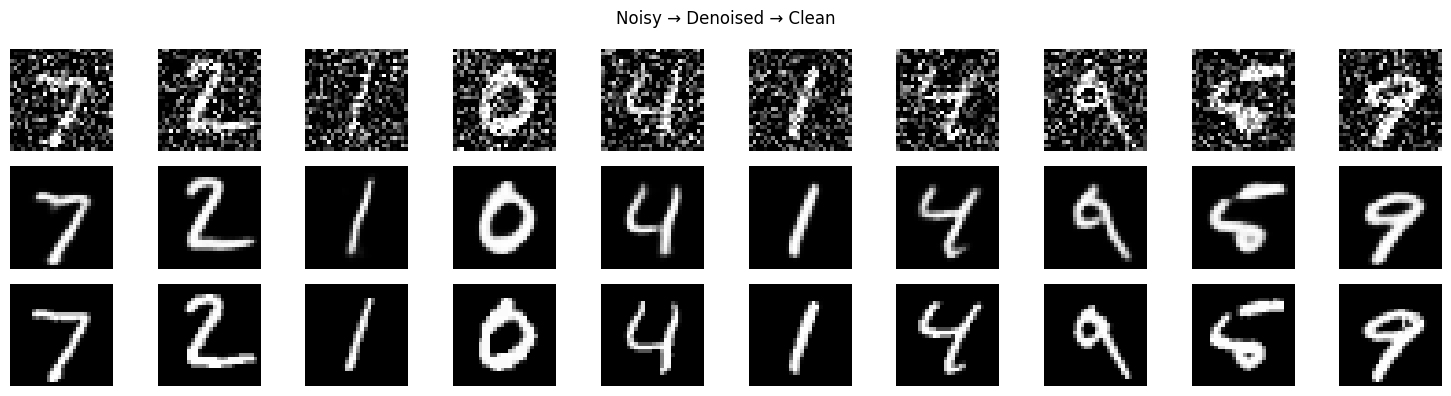

In [9]:
x_denoised = autoencoder.predict(x_test_noisy[:10])

fig, axes = plt.subplots(3, 10, figsize=(15, 4))
titles = ['Noisy', 'Denoised', 'Clean']
data   = [x_test_noisy[:10], x_denoised, x_test[:10]]

for row, (d, title) in enumerate(zip(data, titles)):
    for col in range(10):
        axes[row, col].imshow(d[col].squeeze(), cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(title, fontsize=10)

plt.suptitle('Noisy → Denoised → Clean')
plt.tight_layout()
plt.show()

## 9. Pixel-level Noise Reduction Analysis

In [10]:
mse_noisy    = np.mean((x_test - x_test_noisy) ** 2)
mse_denoised = np.mean((x_test - autoencoder.predict(x_test_noisy, verbose=0)) ** 2)

print(f"MSE (Noisy vs Clean)    : {mse_noisy:.4f}")
print(f"MSE (Denoised vs Clean) : {mse_denoised:.4f}")
print(f"Noise Reduction         : {(1 - mse_denoised/mse_noisy)*100:.1f}%")

MSE (Noisy vs Clean)    : 0.0797
MSE (Denoised vs Clean) : 0.0070
Noise Reduction         : 91.2%


## 10. Experiment — Different Noise Levels

Noise=0.1  MSE=0.0034
Noise=0.3  MSE=0.0050
Noise=0.5  MSE=0.0108
Noise=0.7  MSE=0.0285


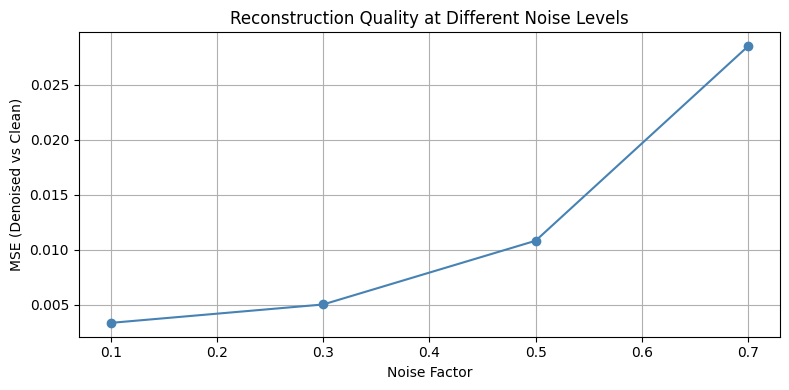

In [11]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
results = []

for nf in noise_levels:
    noisy = np.clip(x_test + nf * np.random.normal(size=x_test.shape), 0, 1)
    denoised = autoencoder.predict(noisy, verbose=0)
    mse = np.mean((x_test - denoised) ** 2)
    results.append(mse)
    print(f"Noise={nf:.1f}  MSE={mse:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(noise_levels, results, marker='o', color='steelblue')
plt.xlabel('Noise Factor')
plt.ylabel('MSE (Denoised vs Clean)')
plt.title('Reconstruction Quality at Different Noise Levels')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. Encoder — Visualize Latent Space

Latent representation shape: (5, 7, 7, 64)


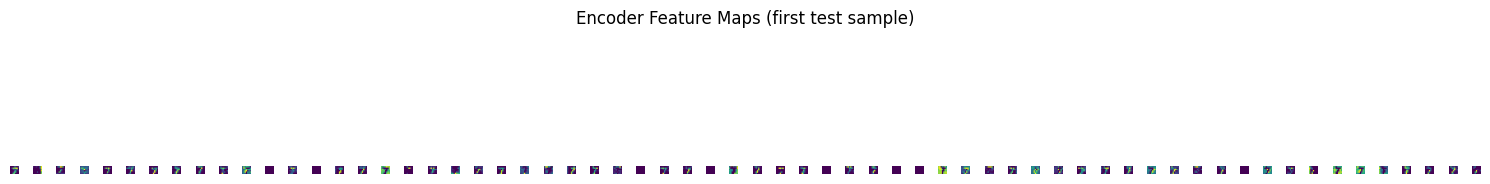

In [12]:
encoder = models.Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer(index=4).output
)

latent = encoder.predict(x_test_noisy[:5], verbose=0)
print("Latent representation shape:", latent.shape)

fig, axes = plt.subplots(1, latent.shape[-1], figsize=(15, 3))
for i in range(latent.shape[-1]):
    axes[i].imshow(latent[0, :, :, i], cmap='viridis')
    axes[i].axis('off')
plt.suptitle('Encoder Feature Maps (first test sample)')
plt.tight_layout()
plt.show()